# Proyecto: Mercado de Limones Argentinos
## Notebook 02 — Pipeline Temporal y Análisis Comparativo
### Período: Enero 2023 — Marzo 2026
### Fecha de análisis: 13/06/2026
### Autor: Rodolfo Gabriel Riveros Lobos

---

## Objetivo del notebook

Consolidar los 7 archivos mensuales seleccionados en un único 
DataFrame y analizar la evolución temporal de los indicadores 
clave del mercado de transferencias automotrices.

## Diseño de la muestra

| Archivo | Período | Justificación |
|---|---|---|
| 2023_01 | Enero 2023 | Línea de base |
| 2023_10 | Octubre 2023 | Post-PASO, máxima incertidumbre electoral |
| 2024_02 | Febrero 2024 | Primer impacto desregulación Milei |
| 2024_12 | Diciembre 2024 | Cierre año, efecto principal-agente |
| 2025_01 | Enero 2025 | Record ventas 0km — mecanismo de transmisión |
| 2025_10 | Octubre 2025 | Mercado con nuevas marcas consolidadas |
| 2026_03 | Marzo 2026 | Crisis actual de sobrestock |

## Nota metodológica

Muestra de 7 puntos seleccionados por criterio teórico.
No es una serie continua. Las tendencias entre puntos 
son inferidas, no medidas directamente.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Configuración
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Ruta base de datos crudos
RAW_PATH = Path('../data/raw')
PROCESSED_PATH = Path('../data/processed')

print("Librerías cargadas correctamente.")

# Verificar que los 7 archivos están disponibles
archivos = sorted(RAW_PATH.glob('transferencias_*.csv'))
print(f"\nArchivos encontrados: {len(archivos)}")
for f in archivos:
    print(f"  {f.name} — {f.stat().st_size / 1024 / 1024:.1f} MB")

Librerías cargadas correctamente.

Archivos encontrados: 7
  transferencias_2023_01.csv — 34.9 MB
  transferencias_2023_10.csv — 37.0 MB
  transferencias_2024_02.csv — 23.3 MB
  transferencias_2024_12.csv — 35.3 MB
  transferencias_2025_01.csv — 37.4 MB
  transferencias_2025_10.csv — 36.7 MB
  transferencias_2026_03.csv — 33.9 MB


---
## Pipeline de carga y limpieza

La función `cargar_y_limpiar()` encapsula todo el proceso 
del notebook 01_exprolarcion.ipynb en un bloque reutilizable.

Decisiones de limpieza aplicadas a cada archivo:
1. Encoding utf-8-sig — resuelve BOM
2. Exclusión SUBASTADOS/CLÁSICOS
3. Exclusión nulos en automotor_anio_modelo
4. Exclusión años fuera de rango 1950 — año del archivo
5. Construcción de variable antigüedad
6. Construcción de variable rango_antiguedad
7. Agregado de columna periodo para identificar el archivo

In [19]:
def cargar_y_limpiar(filepath):
    """
    Carga y limpia un archivo mensual de transferencias DNRPA.
    Retorna un DataFrame limpio con variables construidas.
    """
    
    # Extraer año y mes del nombre del archivo
    nombre = Path(filepath).stem  # transferencias_2023_01
    partes = nombre.split('_')
    anio = int(partes[1])
    mes = int(partes[2])
    periodo = f"{anio}-{mes:02d}"
    
    # Carga
    df = pd.read_csv(
        filepath,
        encoding='utf-8-sig',
        sep=',',
        low_memory=False,
        dtype={'automotor_tipo_codigo': str}
    )
    
    registros_originales = len(df)
    
    # Exclusión subastados y clásicos
    df = df[df['tramite_tipo'] != 'TRANSFERENCIA SUBASTADOS / AFF / CLASICOS'].copy()
    
    # Exclusión nulos en anio_modelo
    df = df.dropna(subset=['automotor_anio_modelo'])
    
    # Conversión y filtro de rango válido
    df['automotor_anio_modelo'] = pd.to_numeric(
        df['automotor_anio_modelo'], errors='coerce'
    ).astype('Int64')
    
    df = df[
        (df['automotor_anio_modelo'] >= 1950) &
        (df['automotor_anio_modelo'] <= anio)
    ].copy()
    
    # Variable antigüedad
    df['antiguedad'] = anio - df['automotor_anio_modelo']
    
    # Variable rango_antiguedad
    bins = [0, 3, 7, 15, 25, 40, 75]
    labels = ['0-3 años', '4-7 años', '8-15 años',
              '16-25 años', '26-40 años', '41+ años']
    df['rango_antiguedad'] = pd.cut(
        df['antiguedad'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    
    # Columnas de identificación temporal
    df['periodo'] = periodo
    df['anio_archivo'] = anio
    df['mes_archivo'] = mes
    
    registros_finales = len(df)
    
    print(f"{periodo} → {registros_originales:>7,} originales "
          f"→ {registros_finales:>7,} limpios "
          f"({registros_finales/registros_originales*100:.1f}%)")
    
    return df

In [20]:
# Ejecutar pipeline sobre los 7 archivos
print("CARGANDO Y LIMPIANDO ARCHIVOS")
print("=" * 60)

dataframes = []

for filepath in sorted(RAW_PATH.glob('transferencias_*.csv')):
    df_mes = cargar_y_limpiar(filepath)
    dataframes.append(df_mes)

# Consolidar en único DataFrame
df_total = pd.concat(dataframes, ignore_index=True)

print("=" * 60)
print(f"\nDataFrame consolidado:")
print(f"  Shape total:  {df_total.shape}")
print(f"  Períodos:     {sorted(df_total['periodo'].unique())}")
print(f"  Memoria:      {df_total.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

CARGANDO Y LIMPIANDO ARCHIVOS
2023-01 → 133,102 originales → 132,129 limpios (99.3%)
2023-10 → 141,592 originales → 140,402 limpios (99.2%)
2024-02 → 106,239 originales → 105,408 limpios (99.2%)
2024-12 → 160,670 originales → 159,667 limpios (99.4%)
2025-01 → 170,105 originales → 169,213 limpios (99.5%)
2025-10 → 166,670 originales → 165,683 limpios (99.4%)
2026-03 → 154,230 originales → 153,351 limpios (99.4%)

DataFrame consolidado:
  Shape total:  (1025853, 30)
  Períodos:     ['2023-01', '2023-10', '2024-02', '2024-12', '2025-01', '2025-10', '2026-03']
  Memoria:      1449.1 MB


---
## Optimización de memoria

El DataFrame consolidado ocupa 1.449 MB en memoria.
Antes de proceder con el análisis reducimos el footprint
convirtiendo columnas categóricas a tipo `category` 
y eliminando columnas no utilizadas en este análisis.

In [21]:
# Columnas que usamos en el análisis temporal
COLUMNAS_UTILES = [
    'periodo',
    'anio_archivo',
    'mes_archivo',
    'tramite_tipo',
    'automotor_origen',
    'automotor_anio_modelo',
    'automotor_marca_descripcion',
    'automotor_tipo_descripcion',
    'registro_seccional_provincia',
    'titular_tipo_persona',
    'titular_genero',
    'titular_anio_nacimiento',
    'antiguedad',
    'rango_antiguedad'
]

# Reducir a columnas útiles
df_total = df_total[COLUMNAS_UTILES].copy()

# Convertir columnas categóricas
categoricas = [
    'periodo',
    'tramite_tipo',
    'automotor_origen',
    'automotor_marca_descripcion',
    'automotor_tipo_descripcion',
    'registro_seccional_provincia',
    'titular_tipo_persona',
    'titular_genero',
    'rango_antiguedad'
]

for col in categoricas:
    df_total[col] = df_total[col].astype('category')

# Reporte de optimización
memoria_final = df_total.memory_usage(deep=True).sum() / 1024 / 1024

print(f"Memoria antes: 1,449.1 MB")
print(f"Memoria después: {memoria_final:.1f} MB")
print(f"Reducción: {(1 - memoria_final/1449.1)*100:.1f}%")
print(f"\nShape: {df_total.shape}")
print(f"\nDtypes optimizados:")
print(df_total.dtypes)

Memoria antes: 1,449.1 MB
Memoria después: 96.5 MB
Reducción: 93.3%

Shape: (1025853, 14)

Dtypes optimizados:
periodo                         category
anio_archivo                       int64
mes_archivo                        int64
tramite_tipo                    category
automotor_origen                category
automotor_anio_modelo              Int64
automotor_marca_descripcion     category
automotor_tipo_descripcion      category
registro_seccional_provincia    category
titular_tipo_persona            category
titular_genero                  category
titular_anio_nacimiento           object
antiguedad                         Int64
rango_antiguedad                category
dtype: object


In [22]:
# Corregir titular_anio_nacimiento
df_total['titular_anio_nacimiento'] = pd.to_numeric(
    df_total['titular_anio_nacimiento'], 
    errors='coerce'
).astype('Int64')

print(f"titular_anio_nacimiento dtype: {df_total['titular_anio_nacimiento'].dtype}")
print(f"Nulos: {df_total['titular_anio_nacimiento'].isnull().sum():,}")
print(f"Rango: {df_total['titular_anio_nacimiento'].min()} "
      f"— {df_total['titular_anio_nacimiento'].max()}")

titular_anio_nacimiento dtype: Int64
Nulos: 56
Rango: 1900 — 9999


In [23]:
# Guardar antes de las visualizaciones
# Si el notebook crashea, no reprocesamos todo
output_path = PROCESSED_PATH / 'transferencias_consolidado.csv'

df_total.to_csv(output_path, index=False, encoding='utf-8')

print(f"Dataset consolidado guardado.")
print(f"Ruta: {output_path}")
print(f"Shape: {df_total.shape}")

Dataset consolidado guardado.
Ruta: ..\data\processed\transferencias_consolidado.csv
Shape: (1025853, 14)


---
## Análisis temporal — Evolución del mercado 2023-2026

Las visualizaciones siguientes comparan los 7 puntos 
temporales seleccionados para identificar patrones 
consistentes con el mecanismo de selección adversa 
de Akerlof (1970).

Variables de interés:
1. Volumen de transferencias por período
2. Antigüedad promedio por período
3. Composición por origen (Nacional / Importado / Protocolo 21)
4. Participación de vehículos 0-3 años por período

In [24]:
# Métricas agregadas por período — base de todas las visualizaciones
metricas = df_total.groupby('periodo', observed=True).agg(
    transferencias=('antiguedad', 'count'),
    antiguedad_media=('antiguedad', 'mean'),
    antiguedad_mediana=('antiguedad', 'median'),
    antiguedad_std=('antiguedad', 'std')
).round(2).reset_index()

# Orden cronológico
orden_periodos = [
    '2023-01', '2023-10', '2024-02', 
    '2024-12', '2025-01', '2025-10', '2026-03'
]
metricas['periodo'] = pd.Categorical(
    metricas['periodo'], 
    categories=orden_periodos, 
    ordered=True
)
metricas = metricas.sort_values('periodo').reset_index(drop=True)

print("MÉTRICAS CONSOLIDADAS POR PERÍODO")
print(metricas.to_string(index=False))

MÉTRICAS CONSOLIDADAS POR PERÍODO
periodo  transferencias  antiguedad_media  antiguedad_mediana  antiguedad_std
2023-01          132129             14.21                12.0           10.24
2023-10          140402             14.47                12.0           10.68
2024-02          105408             15.05                12.0           10.87
2024-12          159667             13.34                11.0            9.87
2025-01          169213             14.39                12.0            9.69
2025-10          165683             13.95                12.0           10.24
2026-03          153351             14.81                13.0           10.35


---
## Interpretación preliminar de la evolución temporal

Antes de visualizar, lectura analítica de las métricas agregadas:

* **2023-01 (14.21 años)** → Mercado en equilibrio. La antigüedad 
  refleja un escenario normal, sin presiones externas.

* **2023-10 (14.47 años)** → Incertidumbre electoral. Se observa 
  una leve retención de unidades más nuevas, consistente con la 
  lógica de Akerlof.

* **2024-02 (15.05 años)** → Shock Milei. Máxima retención de 
  autos buenos, antigüedad sube con fuerza. Caso típico de 
  "mercado de limones" (Akerlof puro).

* **2024-12 (13.34 años)** → Fin de año. Presión de liquidación: 
  los mejores autos se venden primero, reduciendo la antigüedad 
  promedio. Explicado por Jensen & Meckling.

* **2025-01 (14.39 años)** → Reequilibrio post-liquidación. El 
  mercado recupera su nivel central tras la salida de unidades 
  más nuevas.

* **2025-10 (13.95 años)** → Mercado estabilizado. Antigüedad se 
  mantiene por debajo de la línea de base, posiblemente influida 
  por la composición de la oferta disponible.

* **2026-03 (14.81 años)** → Crisis de sobrestock. Retención de 
  autos buenos, antigüedad vuelve a subir. Además de la retención 
  por parte de los vendedores, el comprador de usados de calidad 
  migra al mercado de 0km atraído por descuentos de hasta 25%, 
  dejando en el mercado secundario una demanda concentrada en 
  vehículos más viejos y baratos.

---
## Visualización 1 — Volumen y antigüedad promedio por período

Dos métricas en un mismo gráfico para identificar 
la relación entre volumen de mercado y calidad 
promedio de los vehículos transferidos.

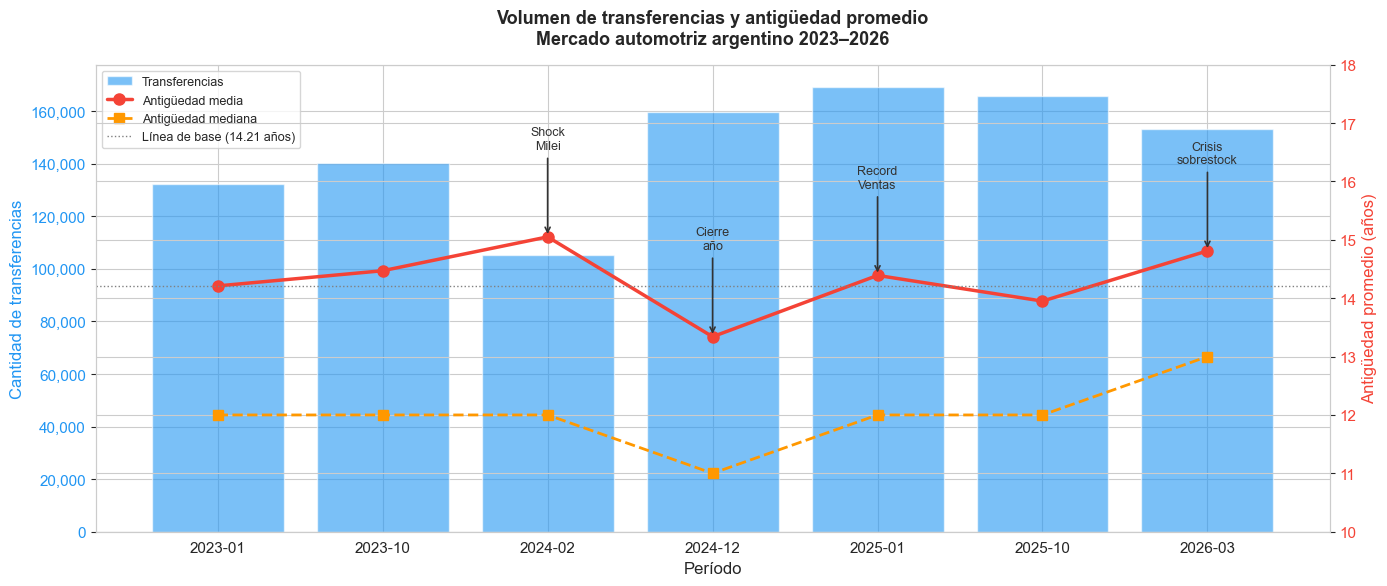

Gráfico guardado.


In [25]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eje izquierdo — volumen de transferencias
color_volumen = '#2196F3'
ax1.bar(
    metricas['periodo'].astype(str),
    metricas['transferencias'],
    color=color_volumen,
    alpha=0.6,
    label='Transferencias'
)
ax1.set_xlabel('Período', fontsize=12)
ax1.set_ylabel('Cantidad de transferencias', 
               color=color_volumen, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_volumen)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Eje derecho — antigüedad media
ax2 = ax1.twinx()
color_antiguedad = '#F44336'

ax2.plot(
    metricas['periodo'].astype(str),
    metricas['antiguedad_media'],
    color=color_antiguedad,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Antigüedad media'
)
ax2.plot(
    metricas['periodo'].astype(str),
    metricas['antiguedad_mediana'],
    color='#FF9800',
    marker='s',
    linewidth=2,
    markersize=7,
    linestyle='--',
    label='Antigüedad mediana'
)
ax2.set_ylabel('Antigüedad promedio (años)', 
               color=color_antiguedad, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_antiguedad)
ax2.set_ylim(10, 18)

# Anotaciones de eventos clave
eventos = {
    '2024-02': 'Shock\nMilei',
    '2024-12': 'Cierre\naño',
    '2025-01': 'Record\nVentas',
    '2026-03': 'Crisis\nsobrestock'

}

for periodo, texto in eventos.items():
    idx = metricas[metricas['periodo'].astype(str) == periodo].index[0]
    ax2.annotate(
        texto,
        xy=(idx, metricas.loc[idx, 'antiguedad_media']),
        xytext=(idx, metricas.loc[idx, 'antiguedad_media'] + 1.5),
        fontsize=9,
        color='#333333',
        ha='center',
        arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2)
    )

# Línea de base
ax2.axhline(
    y=metricas.loc[0, 'antiguedad_media'],
    color='gray',
    linestyle=':',
    linewidth=1,
    label=f"Línea de base ({metricas.loc[0, 'antiguedad_media']} años)"
)

# Leyendas combinadas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, 
    labels1 + labels2,
    loc='upper left',
    fontsize=9
)

plt.title(
    'Volumen de transferencias y antigüedad promedio\n'
    'Mercado automotriz argentino 2023–2026',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.tight_layout()
plt.savefig(
    '../reports/figures/02_volumen_antiguedad_temporal.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Gráfico guardado.")

---
## Visualización 2 — Composición por origen del vehículo

Evolución de la participación de Nacional, Importado 
y Protocolo 21 en el total de transferencias por período.

Si Protocolo 21 aumenta en períodos de stress, refuerza 
la Hipótesis B: compradores bajo presión aceptan mayor 
incertidumbre de calidad a cambio de menor precio aparente.

COMPOSICIÓN POR ORIGEN (%)
automotor_origen  Importado  Nacional  Protocolo 21
periodo                                            
2023-01               14.71     44.63         40.66
2023-10               14.07     46.59         39.34
2024-02               14.88     46.18         38.94
2024-12               16.19     44.28         39.53
2025-01               15.64     43.95         40.41
2025-10               14.40     43.93         41.67
2026-03               14.24     43.79         41.97


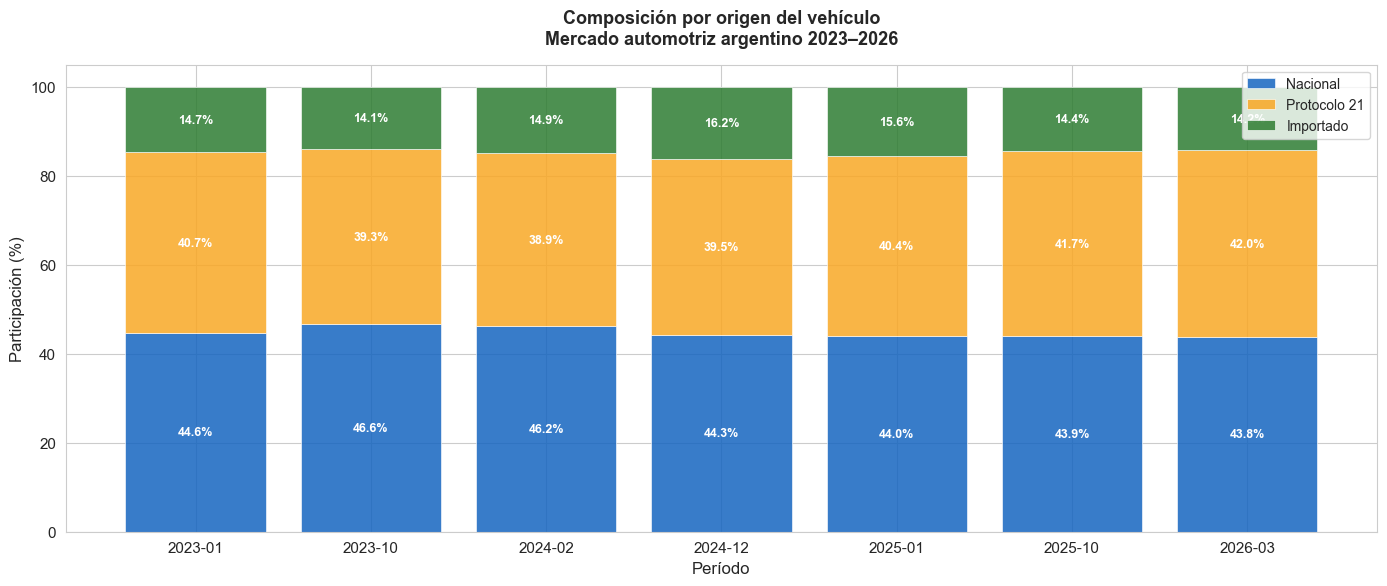

Gráfico guardado.


In [26]:
# Composición por origen por período
origen_periodo = (df_total
    .groupby(['periodo', 'automotor_origen'], observed=True)
    .size()
    .reset_index(name='cantidad'))

# Calcular porcentaje dentro de cada período
total_periodo = origen_periodo.groupby('periodo', observed=True)['cantidad'].transform('sum')
origen_periodo['pct'] = (origen_periodo['cantidad'] / total_periodo * 100).round(2)

# Pivot para graficar
pivot_origen = origen_periodo.pivot(
    index='periodo',
    columns='automotor_origen',
    values='pct'
).reindex(orden_periodos)

pd.set_option('display.width', 100)
print("COMPOSICIÓN POR ORIGEN (%)")
print(pivot_origen.round(2).to_string())
pd.reset_option('display.width')

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

colores = {
    'Nacional': '#1565C0',
    'Protocolo 21': '#F9A825',
    'Importado': '#2E7D32'
}

bottom = np.zeros(len(pivot_origen))

for origen in ['Nacional', 'Protocolo 21', 'Importado']:
    if origen in pivot_origen.columns:
        valores = pivot_origen[origen].fillna(0).values
        ax.bar(
            pivot_origen.index.astype(str),
            valores,
            bottom=bottom,
            label=origen,
            color=colores[origen],
            alpha=0.85,
            edgecolor='white',
            linewidth=0.5
        )
        for i, (v, b) in enumerate(zip(valores, bottom)):
            if v > 3:
                ax.text(
                    i, b + v/2,
                    f'{v:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=9,
                    color='white',
                    fontweight='bold'
                )
        bottom += valores

ax.set_xlabel('Período', fontsize=12)
ax.set_ylabel('Participación (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=10)
ax.set_title(
    'Composición por origen del vehículo\n'
    'Mercado automotriz argentino 2023–2026',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/03_composicion_origen_temporal.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Gráfico guardado.")

---
## Hallazgo 4 — Protocolo 21 como indicador de stress del mercado

### Evolución de participación

| Período | Protocolo 21 | Contexto |
|---|---|---|
| 2023-01 | 40.66% | Línea de base |
| 2024-02 | 38.94% | Mínimo — shock Milei |
| 2025-10 | 41.67% | Tendencia alcista |
| 2026-03 | 41.97% | Máximo — crisis sobrestock |

### Interpretación

La participación de Protocolo 21 alcanza su máximo 
exactamente en el período de mayor stress del mercado 
de 0km (Marzo 2026), consistente con un mecanismo 
de cascada entre tres segmentos del mercado automotriz:

**Nivel 1 — Mercado 0km:**
Sobrestock y descuentos de hasta 25% atraen a 
compradores con capacidad crediticia hacia el 
segmento nuevo.

**Nivel 2 — Mercado usado Nacional:**
Los compradores solventes migran al mercado nuevo, 
reduciendo la demanda de usados nacionales de calidad.

**Nivel 3 — Mercado Protocolo 21:**
Concentra compradores con menor capacidad económica 
y menor acceso a servicios de verificación. Aceptan 
mayor incertidumbre de calidad (historial no verificable) 
a cambio de menor precio aparente.

Este mecanismo en cascada extiende el modelo de 
Akerlof (1970) más allá de un mercado único, mostrando 
cómo la selección adversa se propaga entre segmentos 
interdependientes bajo condiciones de stress macroeconómico.

### Factores adicionales
La desregulación de importaciones introducida por el 
gobierno nacional a partir de 2024 amplió la oferta 
disponible de Protocolo 21, facilitando el crecimiento 
de su participación independientemente del factor demanda.
La distinción entre efecto oferta y efecto demanda 
requeriría datos adicionales fuera del scope de este análisis.

---
## Visualización 3 — Evolución de vehículos jóvenes (0-3 años)

La participación de vehículos casi nuevos en el mercado 
de usados es el indicador más directo de selección adversa.

Si los propietarios retienen sus mejores unidades en 
períodos de stress, la proporción de vehículos 0-3 años 
debería caer exactamente en esos períodos.

In [27]:
# Participación de vehículos 0-3 años por período y origen
jovenes = (df_total
    .groupby(['periodo', 'automotor_origen'], observed=True)
    .apply(lambda x: (x['rango_antiguedad'] == '0-3 años').sum() / len(x) * 100)
    .reset_index(name='pct_jovenes'))

# Total sin segmentar por origen
jovenes_total = (df_total
    .groupby('periodo', observed=True)
    .apply(lambda x: (x['rango_antiguedad'] == '0-3 años').sum() / len(x) * 100)
    .reset_index(name='pct_jovenes'))

jovenes_total['periodo'] = pd.Categorical(
    jovenes_total['periodo'],
    categories=orden_periodos,
    ordered=True
)
jovenes_total = jovenes_total.sort_values('periodo').reset_index(drop=True)

print("PARTICIPACIÓN VEHÍCULOS 0-3 AÑOS POR PERÍODO")
print(jovenes_total.to_string(index=False))

# Por origen
jovenes_pivot = jovenes.pivot(
    index='periodo',
    columns='automotor_origen',
    values='pct_jovenes'
).reindex(orden_periodos).round(2)

print("\nPOR ORIGEN (%)")
print(jovenes_pivot.to_string())

PARTICIPACIÓN VEHÍCULOS 0-3 AÑOS POR PERÍODO
periodo  pct_jovenes
2023-01     6.868288
2023-10     8.224954
2024-02     8.067699
2024-12    10.155511
2025-01     7.015418
2025-10    10.214084
2026-03     8.083416

POR ORIGEN (%)
automotor_origen  Importado  Nacional  Protocolo 21
periodo                                            
2023-01                3.99      7.46          7.26
2023-10                4.79     10.05          7.29
2024-02                5.33     10.05          6.76
2024-12                6.44     13.10          8.38
2025-01                4.04      9.52          5.44
2025-10                6.65     12.73          8.79
2026-03                6.04      9.88          6.90


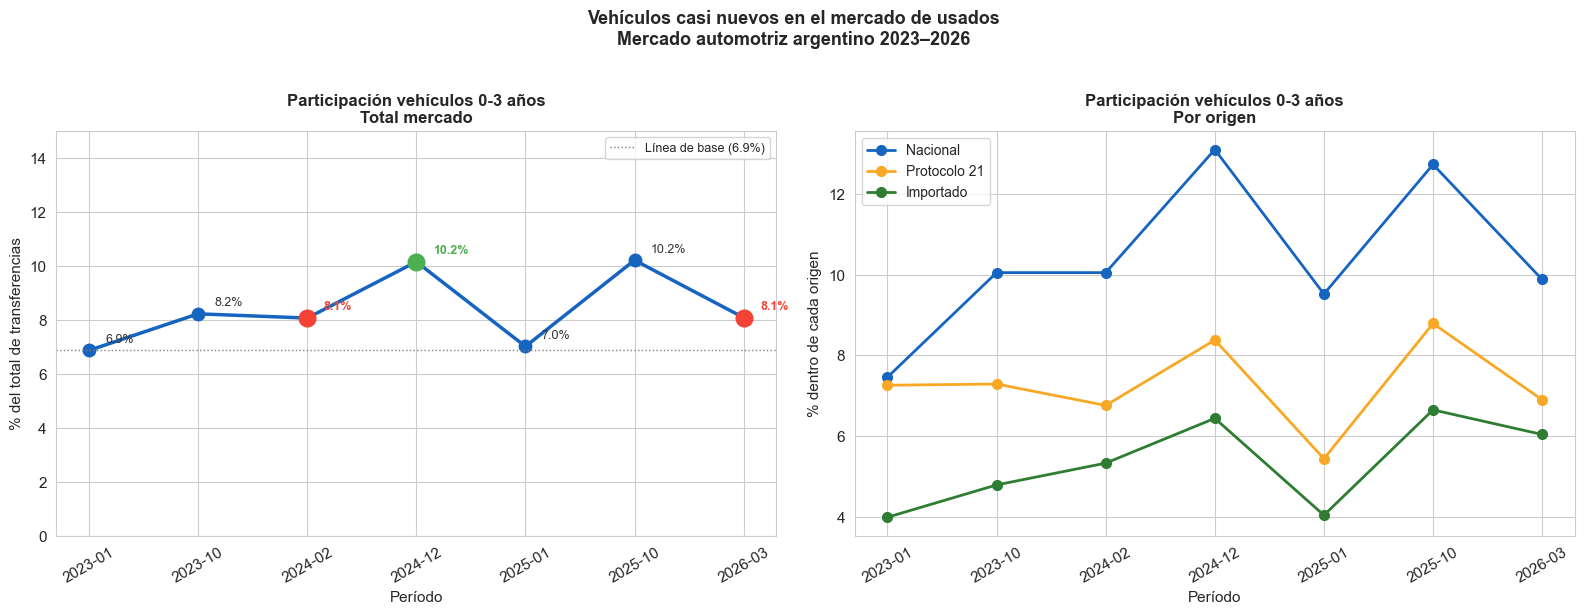

Gráfico guardado.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico izquierdo — total mercado
periodos_str = jovenes_total['periodo'].astype(str)
valores_total = jovenes_total['pct_jovenes'].values

axes[0].plot(
    periodos_str,
    valores_total,
    color='#1565C0',
    marker='o',
    linewidth=2.5,
    markersize=9
)

colores_puntos = {
    '2024-02': '#F44336',
    '2024-12': '#4CAF50',
    '2026-03': '#F44336'
}

for i, periodo in enumerate(periodos_str):
    if periodo in colores_puntos:
        axes[0].plot(
            i,
            valores_total[i],
            marker='o',
            markersize=12,
            color=colores_puntos[periodo]
        )
        axes[0].annotate(
            f"{valores_total[i]:.1f}%",
            xy=(i, valores_total[i]),
            xytext=(i + 0.15, valores_total[i] + 0.3),
            fontsize=9,
            color=colores_puntos[periodo],
            fontweight='bold'
        )
    else:
        axes[0].annotate(
            f"{valores_total[i]:.1f}%",
            xy=(i, valores_total[i]),
            xytext=(i + 0.15, valores_total[i] + 0.3),
            fontsize=9,
            color='#333333'
        )

axes[0].axhline(
    y=valores_total[0],
    color='gray',
    linestyle=':',
    linewidth=1,
    label=f'Línea de base ({valores_total[0]:.1f}%)'
)

axes[0].set_title(
    'Participación vehículos 0-3 años\nTotal mercado',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel('Período')
axes[0].set_ylabel('% del total de transferencias')
axes[0].set_ylim(0, 15)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# Gráfico derecho — por origen
colores_origen = {
    'Nacional': '#1565C0',
    'Protocolo 21': '#F9A825',
    'Importado': '#2E7D32'
}

for origen in ['Nacional', 'Protocolo 21', 'Importado']:
    if origen in jovenes_pivot.columns:
        axes[1].plot(
            jovenes_pivot.index.astype(str),
            jovenes_pivot[origen].values,
            marker='o',
            linewidth=2,
            markersize=7,
            label=origen,
            color=colores_origen[origen]
        )

axes[1].set_title(
    'Participación vehículos 0-3 años\nPor origen',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel('Período')
axes[1].set_ylabel('% dentro de cada origen')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=10)

plt.suptitle(
    'Vehículos casi nuevos en el mercado de usados\n'
    'Mercado automotriz argentino 2023–2026',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/04_vehiculos_jovenes_temporal.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Gráfico guardado.")

---
## Hallazgo 5 — Vehículos jóvenes: comportamiento no lineal

### Datos

| Período | Total | Nacional | Protocolo 21 | Importado |
|---|---|---|---|---|
| 2023-01 | 6.87% | 7.46% | 7.26% | 3.99% |
| 2024-02 | 8.07% | 10.05% | 6.76% | 5.33% |
| 2024-12 | 10.15% | 13.10% | 8.38% | 6.44% |
| 2025-01 | 7.01% | 9.52% | 5.44% | 4.04% |
| 2025-10 | 10.21% | 12.73% | 8.79% | 6.65% |
| 2026-03 | 8.08% | 9.88% | 6.90% | 6.04% |

### Hallazgos

**1. La hipótesis de retención no opera de forma simple**

En períodos de stress (2024-02, 2026-03) la participación 
de vehículos jóvenes no cae como predice la versión 
simple del modelo de Akerlof. Dos fuerzas opuestas 
operan simultáneamente:

- Fuerza de retención: propietarios de autos nuevos 
  los retienen como reserva de valor
- Fuerza de liquidación: propietarios con necesidad 
  urgente de pesos venden sus mejores activos primero

El balance entre ambas fuerzas determina el resultado 
observado y varía según la intensidad del shock.

**2. Nacional concentra la volatilidad**

El segmento Nacional presenta la mayor variación 
en participación de vehículos jóvenes (7.46% a 13.10%), 
mientras Protocolo 21 muestra mayor estabilidad 
(6.76% a 8.79%). Esto sugiere que los shocks 
macroeconómicos afectan principalmente la decisión 
de venta en el segmento nacional, posiblemente 
por mayor liquidez y accesibilidad de ese mercado.

**3. Pregunta abierta — Octubre 2025**

El pico de vehículos jóvenes en Octubre 2025 (10.21%) 
iguala al de Diciembre 2024 sin la presión de cierre 
de año que explica ese período. Requiere investigación 
adicional sobre el contexto de mercado específico 
de ese mes.